<a href="https://colab.research.google.com/github/neaneen/IWS1-Sorting-Slambekova/blob/main/QuickSortHoare.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
def hoare_partition(arr, low, high): #разбиение по Хоара

    pivot = arr[(low + high) // 2]  # опорный элемент(середина)

    i = low - 1  # левый указатель
    j = high + 1  # правый указатель

    while True:  #цикл разбиения

        i += 1  # левый указатель вправо
        while arr[i] < pivot:  # элемент >= pivot
            i += 1

        j -= 1  # правый указатель влево
        while arr[j] > pivot:  # элемент <= pivot
            j -= 1

        if i >= j:  # если указатели пересеклись
            return j  # возвращаем индекс разделения

        arr[i], arr[j] = arr[j], arr[i]  # меняем элементы местами

In [4]:
def quick_sort(arr, low, high):  # рекурсивная сортировка

    if low < high:

        p = hoare_partition(arr, low, high)

        quick_sort(arr, low, p)  # левая часть
        quick_sort(arr, p + 1, high)  # правая часть

In [5]:
import random  # библиотека для генерации случайных чисел

def random_array(n):  # случайный массив
    return [random.randint(0, 100000) for _ in range(n)]


def sorted_array(n):  # полностью отсортированный массив
    return list(range(n))


def reversed_array(n):  # обратный порядок
    return list(range(n, 0, -1))


def almost_sorted_array(n):  # почти отсортированный массив

    arr = list(range(n))  #отсортированный массив

    swaps = n // 20  #случайные перестановки

    for _ in range(swaps):  # выполняем несколько случайных обменов

        i = random.randint(0, n - 1)  # случайный индекс
        j = random.randint(0, n - 1)  # второй случайный индекс

        arr[i], arr[j] = arr[j], arr[i]  # меняем элементы местами

    return arr  # возвращаем массив

In [6]:
import time # модуль для измерения времени

def measure_quick(arr):  # измерение quick sort

    arr_copy = arr.copy()  # копируем массив

    start = time.perf_counter()

    quick_sort(arr_copy, 0, len(arr_copy) - 1)

    end = time.perf_counter()

    return end - start

In [7]:
def average_time(generator, n, runs=5): # функция усреднения времени

    times = [] # список для хранения

    for _ in range(runs):

        arr = generator(n)

        t = measure_quick(arr) # измеряем время

        times.append(t)  # сохраняем результат

    return sum(times) / len(times)  # возвращаем среднее время

In [8]:
sizes = [1000, 5000, 10000, 50000]

random_times = []
sorted_times = []
reversed_times = []
almost_sorted_times = []

for n in sizes:

    t_random = average_time(random_array, n)
    t_sorted = average_time(sorted_array, n)
    t_reversed = average_time(reversed_array, n)
    t_almost = average_time(almost_sorted_array, n)

    random_times.append(t_random)
    sorted_times.append(t_sorted)
    reversed_times.append(t_reversed)
    almost_sorted_times.append(t_almost)

    print("Размер:", n)
    print("Случайный:", t_random)
    print("Отсортированный:", t_sorted)
    print("Обратный:", t_reversed)
    print("Почти отсортированный:", t_almost)
    print()

Размер: 1000
Случайный: 0.0015428726001118775
Отсортированный: 0.0009004656000797695
Обратный: 0.0009759115999258938
Почти отсортированный: 0.0008929844000704179

Размер: 5000
Случайный: 0.007333598800050823
Отсортированный: 0.0051296382001055464
Обратный: 0.005070848800096428
Почти отсортированный: 0.005057670600126585

Размер: 10000
Случайный: 0.015472393799973361
Отсортированный: 0.011213922600018123
Обратный: 0.010563161399841193
Почти отсортированный: 0.01062086799993267

Размер: 50000
Случайный: 0.09646555679992161
Отсортированный: 0.057645852799942075
Обратный: 0.06254566380002871
Почти отсортированный: 0.06217237219998424



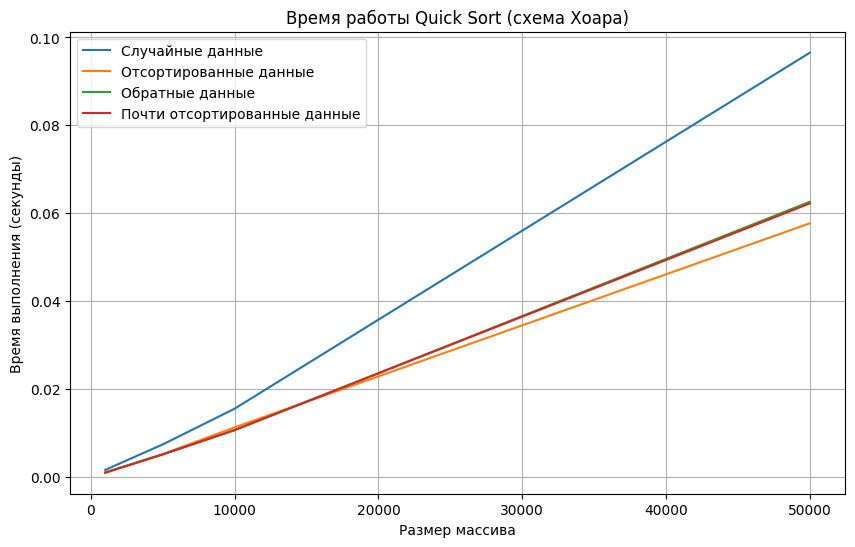

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(sizes, random_times, label="Случайные данные")
plt.plot(sizes, sorted_times, label="Отсортированные данные")
plt.plot(sizes, reversed_times, label="Обратные данные")
plt.plot(sizes, almost_sorted_times, label="Почти отсортированные данные")

plt.xlabel("Размер массива")
plt.ylabel("Время выполнения (секунды)")
plt.title("Время работы Quick Sort (схема Хоара)")

plt.legend()
plt.grid(True)

plt.show()